# Forgetting Analysis — True-Peak FM (Fig. S1, Fig. 4)

Evaluates catastrophic forgetting for all 8 continual learning classifiers using the
**True-Peak FM**: `FM_j = max_t R[t,j] − R[N-1,j]`, always ≥ 0. Avoids the diagonal-anchor
artefact where ramp-up classifiers (e.g. Replay) appear to have negative forgetting.

**Fig. S1** — Combined: FM bar chart + per-class drop heatmap + temporal FM curve.
**Fig. 4** — Per-class accuracy evolution R[t,j] heatmap.

**Protocol**: 40-class 1-shot OpenLORIS, 3 seeds. R[t, j, c, s] = accuracy of class `j`
after step `t`, classifier `c`, seed `s`.

Run the experiment script first (or set `RUN_EXPERIMENT = True`):
```bash
python experiments/forgetting_experiments_1shot.py
```

In [24]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

REPO = Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

RESULTS_DIR = REPO / "experiments" / "results" / "forgetting"
IMAGES_DIR  = REPO / "images"
IMAGES_DIR.mkdir(exist_ok=True)

RUN_EXPERIMENT = False  # set True to re-run (slow: ~60 min)

In [25]:
if RUN_EXPERIMENT:
    import subprocess
    subprocess.run([sys.executable,
                    str(REPO / "experiments" / "forgetting_experiments_1shot.py")],
                   check=True)

## Load R matrix

In [26]:
# forgetting_experiments_1shot.py saves the R matrix as a raw .npy file
# (no embedded class-name array), so we define the classifier list locally —
# it must match CLASSIFIER_TYPES / CLASSIFIER_DISPLAY_NAMES in the script.

R = np.load(RESULTS_DIR / "R_matrix_1shot.npy")   # shape (40, 40, 8, 3)

CLASSIFIERS = [
    "perceptron", "fine_tune", "ncm", "replay_20",
    "slda", "slda_const_sigma", "clp", "clp_snn",
]
DISPLAY_NAMES = [
    "Perceptron", "Fine Tuning", "NCM", "Replay",
    "SLDA", "SLDA (Frozen Σ)", "CLP", "CLP-SNN",
]

p          = sns.color_palette("tab10")
COLORS     = ['#606060', '#B0B0B0', p[2], p[3], p[1], p[1], p[9], p[9]]
LINESTYLES = ["-", "-", "-", "-", "--", ":", "-", "-."]

NUM_CLASSES = R.shape[0]
N_SEEDS     = R.shape[3]
N_CLF       = len(CLASSIFIERS)

print(f"R shape: {R.shape}")
print("Classifiers:", CLASSIFIERS)

R shape: (40, 40, 8, 3)
Classifiers: ['perceptron', 'fine_tune', 'ncm', 'replay_20', 'slda', 'slda_const_sigma', 'clp', 'clp_snn']


## Compute True-Peak FM

In [27]:
N = NUM_CLASSES
fm_all   = np.full((N_CLF, N_SEEDS), np.nan)
fm_curve = np.full((N - 1, N_CLF, N_SEEDS), np.nan)

for c in range(N_CLF):
    for s in range(N_SEEDS):
        # True-Peak FM
        fm_terms = []
        for j in range(N - 1):
            pk    = np.nanmax(R[:, j, c, s])
            final = R[N-1, j, c, s]
            if np.isnan(pk) or np.isnan(final):
                continue
            fm_terms.append(pk - final)
        fm_all[c, s] = np.mean(fm_terms) if fm_terms else np.nan

        # Temporal FM curve
        for t_idx, t in enumerate(range(1, N)):
            fm_t = []
            for j in range(t):
                run_peak = np.nanmax(R[j:t+1, j, c, s])
                rtj = R[t, j, c, s]
                if np.isnan(run_peak) or np.isnan(rtj):
                    continue
                fm_t.append(run_peak - rtj)
            fm_curve[t_idx, c, s] = np.mean(fm_t) if fm_t else np.nan

fm_mean = np.nanmean(fm_all, axis=1)
fm_std  = np.nanstd(fm_all,  axis=1)
fm_curve_mean = np.nanmean(fm_curve, axis=2)
fm_curve_std  = np.nanstd(fm_curve,  axis=2)

peak_R = np.nanmax(R, axis=0)
per_class_drop = np.nanmean(peak_R - R[N-1, :, :, :], axis=-1)  # (N, N_CLF)
per_class_drop_mat = per_class_drop.T  # (N_CLF, N)

print("True-Peak FM (mean ± std):")
for c, name in enumerate(DISPLAY_NAMES):
    print(f"  {name:<22}: {fm_mean[c]*100:.1f} ± {fm_std[c]*100:.1f}%")

True-Peak FM (mean ± std):
  Perceptron            : 55.1 ± 1.1%
  Fine Tuning           : 64.9 ± 1.6%
  NCM                   : 12.2 ± 2.6%
  Replay                : 16.7 ± 1.4%
  SLDA                  : 14.7 ± 3.0%
  SLDA (Frozen Σ)       : 12.3 ± 2.3%
  CLP                   : 11.3 ± 2.3%
  CLP-SNN               : 12.9 ± 1.7%


## FM Summary Table

In [28]:
df = pd.DataFrame({
    "Classifier":   DISPLAY_NAMES,
    "FM (%) mean":  [f"{v*100:.2f}" for v in fm_mean],
    "FM (%) std":   [f"{v*100:.2f}" for v in fm_std],
})
df

,Classifier,FM (%) mean,FM (%) std
0,Perceptron,55.07,1.10
1,Fine Tuning,64.90,1.56
2,NCM,12.19,2.63
3,Replay,16.67,1.42
4,SLDA,14.70,3.04
5,SLDA (Frozen Σ),12.31,2.26
6,CLP,11.27,2.27
7,CLP-SNN,12.88,1.70


## Per-class Accuracy Evolution Heatmap (**Figure 4**)

C:\Users\elvin\AppData\Local\Temp\ipykernel_29956\3069151767.py:2: RuntimeWarning: Mean of empty slice
  R_seed = np.nanmean(R, axis=-1)
C:\Users\elvin\AppData\Local\Temp\ipykernel_29956\3069151767.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


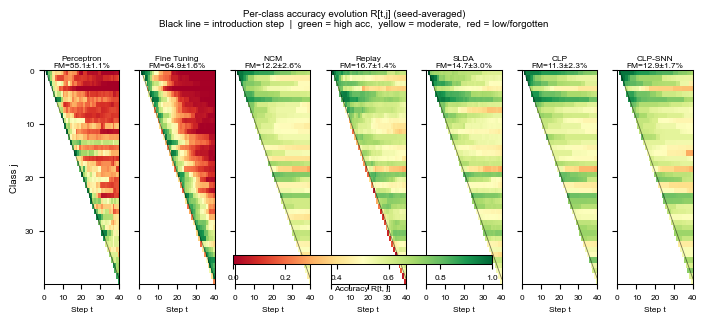

Saved to c:\Users\elvin\dev\CLP-SNN\images


In [35]:
N = NUM_CLASSES
R_seed = np.nanmean(R, axis=-1)
raw_acc = R_seed.copy()
for t in range(N):
    for j in range(t + 1, N):
        raw_acc[t, j, :] = np.nan

hm_idx    = [0, 1, 2, 3, 4, 6, 7]
hm_labels = [DISPLAY_NAMES[i] for i in hm_idx]

fig, axes = plt.subplots(1, len(hm_idx), figsize=(7.087, 2.8), sharey=True)
for col, ci in enumerate(hm_idx):
    ax  = axes[col]
    mat = raw_acc[:, :, ci].T
    im  = ax.imshow(mat, aspect="auto", origin="upper",
                    extent=[1, N, N, 0], vmin=0.0, vmax=1.0,
                    cmap="RdYlGn", interpolation="nearest")
    ax.plot(np.arange(1, N + 1), np.arange(N), "k-", linewidth=0.6, alpha=0.5)
    title = f"{hm_labels[col]}\nFM={fm_mean[ci]*100:.1f}±{fm_std[ci]*100:.1f}%"
    ax.set_title(title, fontsize=6, pad=2)
    ax.set_xlabel("Step t", fontsize=6)
    ax.tick_params(labelsize=6)
    ax.set_xticks(np.arange(0, N + 1, 10))
    ax.set_yticks(np.arange(0, N, 10))
    if col == 0:
        ax.set_ylabel("Class j")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                    fraction=0.04, pad=0.18, shrink=0.6, aspect=30)
cbar.ax.tick_params(labelsize=6)
cbar.set_label("Accuracy R[t, j]", fontsize=6)
fig.suptitle(
    "Per-class accuracy evolution R[t,j] (seed-averaged)\n"
    "Black line = introduction step  |  green = high acc,  yellow = moderate,  red = low/forgotten",
    fontsize=7, y=1.02,
)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(IMAGES_DIR / f"per_class_acc_heatmap_1shot.{ext}", format=ext, bbox_inches="tight")
plt.show()
print("Saved to", IMAGES_DIR)

## Combined: FM bar chart + per-class heatmap + temporal FM curve (**Fig. S1**)

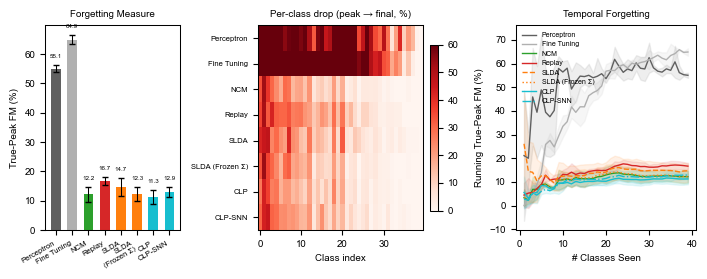

Saved to c:\Users\elvin\dev\CLP-SNN\images


In [34]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6,
    "lines.linewidth": 1,
    "axes.linewidth": 0.75,
    "savefig.dpi": 600,
})

ct_labels = ["Perceptron", "Fine Tuning", "NCM", "Replay",
             "SLDA", "SLDA\n(Frozen Σ)", "CLP", "CLP-SNN"]
x = np.arange(len(DISPLAY_NAMES))

fig, axes = plt.subplots(1, 3, figsize=(7.087, 2.8),
                          gridspec_kw={"width_ratios": [1.5, 2, 2]})

# ── Left: FM bar chart (vertical) ────────────────────────────────────────────
ax = axes[0]
ax.bar(x, fm_mean * 100, yerr=fm_std * 100, color=COLORS,
       width=0.6, capsize=2, error_kw={"linewidth": 0.75})
for i, (val, std) in enumerate(zip(fm_mean * 100, fm_std * 100)):
    ax.text(x[i], val + abs(std) + 2.0, f"{val:.1f}",
            ha="center", va="bottom", fontsize=4.5)
ax.set_xticks(x)
ax.set_xticklabels(ct_labels, rotation=30, ha="right", fontsize=5.5)
ax.set_ylabel("True-Peak FM (%)")
ax.set_title("Forgetting Measure")

# ── Middle: per-class heatmap ─────────────────────────────────────────────────
ax = axes[1]
im = ax.imshow(per_class_drop_mat * 100, aspect="auto", cmap="Reds", vmin=0, vmax=60)
ax.set_yticks(np.arange(N_CLF))
ax.set_yticklabels(DISPLAY_NAMES, fontsize=5.5)
ax.set_xlabel("Class index")
ax.set_title("Per-class drop (peak → final, %)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Right: temporal FM curve ──────────────────────────────────────────────────
ax = axes[2]
t_axis = np.arange(1, N)
for i in range(N_CLF):
    ax.plot(t_axis, fm_curve_mean[:, i] * 100, color=COLORS[i],
            linestyle=LINESTYLES[i], label=DISPLAY_NAMES[i])
    ax.fill_between(t_axis,
                    (fm_curve_mean[:, i] - fm_curve_std[:, i]) * 100,
                    (fm_curve_mean[:, i] + fm_curve_std[:, i]) * 100,
                    color=COLORS[i], alpha=0.1)
ax.set_xlabel("# Classes Seen")
ax.set_ylabel("Running True-Peak FM (%)")
ax.set_title("Temporal Forgetting")
ax.legend(frameon=False, fontsize=5, loc="upper left")

plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(IMAGES_DIR / f"forgetting_metrics_combined_1shot.{ext}",
                format=ext, bbox_inches="tight")
plt.show()
print("Saved to", IMAGES_DIR)

## FM Bar Chart (all 8 classifiers)

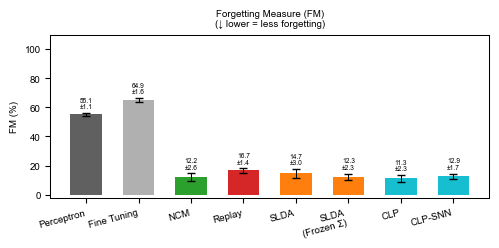

Saved to c:\Users\elvin\dev\CLP-SNN\images


In [30]:
ct_labels = ["Perceptron", "Fine Tuning", "NCM", "Replay",
             "SLDA", "SLDA\n(Frozen Σ)", "CLP", "CLP-SNN"]
x     = np.arange(len(ct_labels))
width = 0.6

fig, ax = plt.subplots(figsize=(5.0, 2.5))
ax.bar(x, fm_mean * 100, width, yerr=fm_std * 100, capsize=3,
       color=COLORS, error_kw=dict(elinewidth=0.75, ecolor="black"))
for i, (val, std) in enumerate(zip(fm_mean * 100, fm_std * 100)):
    ax.text(x[i], val + abs(std) + 2.5, f"{val:.1f}\n±{std:.1f}",
            ha="center", va="bottom", fontsize=4.8, linespacing=1.1)
y_hi_fm = float((fm_mean * 100 + fm_std * 100).max())
ax.set_ylim(-2, y_hi_fm * 1.65)
ax.set_xticks(x)
ax.set_xticklabels(ct_labels, rotation=15, ha="right")
ax.set_ylabel("FM (%)")
ax.set_title("Forgetting Measure (FM)\n(↓ lower = less forgetting)")
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(IMAGES_DIR / f"forgetting_metrics_1shot.{ext}", format=ext, bbox_inches="tight")
plt.show()
print("Saved to", IMAGES_DIR)

## True-Peak FM Temporal Curve

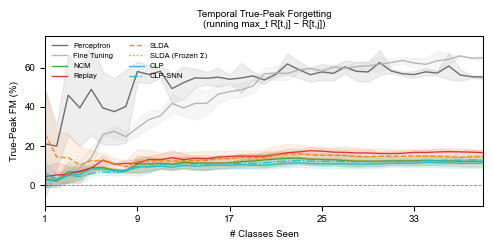

Saved to c:\Users\elvin\dev\CLP-SNN\images


In [31]:
t_axis = np.arange(1, N)

fig, ax = plt.subplots(figsize=(5.0, 2.5))
for i in range(N_CLF):
    ax.plot(t_axis, fm_curve_mean[:, i] * 100, color=COLORS[i],
            linestyle=LINESTYLES[i], label=DISPLAY_NAMES[i], alpha=0.9)
    ax.fill_between(t_axis,
                    (fm_curve_mean[:, i] - fm_curve_std[:, i]) * 100,
                    (fm_curve_mean[:, i] + fm_curve_std[:, i]) * 100,
                    color=COLORS[i], alpha=0.1)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_xlabel("# Classes Seen")
ax.set_ylabel("True-Peak FM (%)")
ax.set_title("Temporal True-Peak Forgetting\n(running max_t R[t,j] − R[t,j])")
ax.set_xlim([1, N - 1])
ax.set_xticks(np.arange(1, N, 8))
ax.legend(loc="upper left", frameon=False, ncol=2, fontsize=5.5)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(IMAGES_DIR / f"forgetting_curves_1shot.{ext}", format=ext, bbox_inches="tight")
plt.show()
print("Saved to", IMAGES_DIR)

## Per-class Forgetting and R Matrix Heatmap

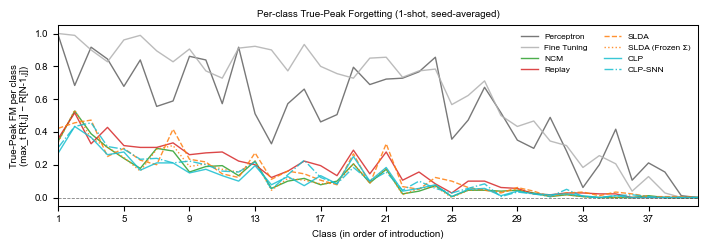

C:\Users\elvin\AppData\Local\Temp\ipykernel_29956\143236368.py:25: RuntimeWarning: Mean of empty slice
  R_avg   = np.nanmean(R, axis=-1)
C:\Users\elvin\AppData\Local\Temp\ipykernel_29956\143236368.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


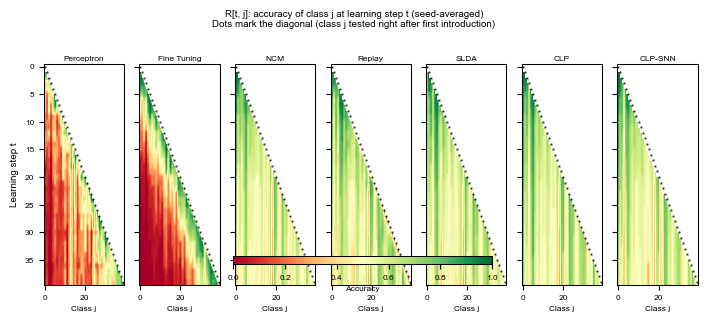

Saved to c:\Users\elvin\dev\CLP-SNN\images


In [32]:
N = NUM_CLASSES

# True-Peak FM per class: max_t R[t,j] − R[N-1,j]
peak_R_per_class = np.nanmax(R, axis=0)  # (N, N_CLF, N_SEEDS)
per_class_frgt = np.nanmean(peak_R_per_class - R[N - 1, :, :, :], axis=-1)  # (N, N_CLF)

fig, ax = plt.subplots(figsize=(7.087, 2.5))
for i in range(N_CLF):
    ax.plot(np.arange(N) + 1, per_class_frgt[:, i],
            color=COLORS[i], linestyle=LINESTYLES[i],
            linewidth=1.0, label=DISPLAY_NAMES[i], alpha=0.85)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_xlabel("Class (in order of introduction)")
ax.set_ylabel("True-Peak FM per class\n(max_t R[t,j] − R[N-1,j])")
ax.set_title("Per-class True-Peak Forgetting (1-shot, seed-averaged)")
ax.set_xlim([1, N])
ax.set_xticks(np.arange(1, N + 1, 4))
ax.legend(loc="upper right", frameon=False, ncol=2)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(IMAGES_DIR / f"per_class_forgetting_1shot.{ext}", format=ext, bbox_inches="tight")
plt.show()

# R matrix heatmap (all classifiers except SLDA Frozen Σ)
R_avg   = np.nanmean(R, axis=-1)
hm_idx  = [0, 1, 2, 3, 4, 6, 7]
hm_labels = [DISPLAY_NAMES[i] for i in hm_idx]

fig, axes = plt.subplots(1, len(hm_idx), figsize=(7.087, 2.8), sharey=True)
for col, ci in enumerate(hm_idx):
    ax  = axes[col]
    mat = R_avg[:, :, ci]
    im  = ax.imshow(mat, aspect="auto", origin="upper", vmin=0, vmax=1, cmap="RdYlGn")
    for j in range(N):
        ax.plot(j, j, "k.", markersize=1.5, alpha=0.6)
    ax.set_title(hm_labels[col], fontsize=6, pad=2)
    ax.set_xlabel("Class j", fontsize=6)
    ax.tick_params(labelsize=6)
    if col == 0:
        ax.set_ylabel("Learning step t")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                    fraction=0.04, pad=0.18, shrink=0.6, aspect=30)
cbar.ax.tick_params(labelsize=6)
cbar.set_label("Accuracy", fontsize=6)
fig.suptitle(
    "R[t, j]: accuracy of class j at learning step t (seed-averaged)\n"
    "Dots mark the diagonal (class j tested right after first introduction)",
    fontsize=7, y=1.02,
)
plt.tight_layout()
for ext in ("pdf", "png"):
    plt.savefig(IMAGES_DIR / f"R_matrix_heatmap_1shot.{ext}", format=ext, bbox_inches="tight")
plt.show()
print("Saved to", IMAGES_DIR)